<a href="https://colab.research.google.com/github/spavithra978/Driver_Drowsiness_Detection./blob/main/Driver_Drowsiness_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow opencv-python matplotlib scikit-learn

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/DriverDrowsinessDataset"

In [ ]:
#--------------🚀 STEP 2 — Load & Explore Dataset (EDA)----------------

In [ ]:
# Define dataset paths
train_dir = dataset_path + "/train"
val_dir = dataset_path + "/validation"
test_dir = dataset_path + "/test"

# Print paths to verify
print("Train Path:", train_dir)
print("Validation Path:", val_dir)
print("Test Path:", test_dir)

Train Path: /content/drive/MyDrive/DriverDrowsinessDataset/train
Validation Path: /content/drive/MyDrive/DriverDrowsinessDataset/validation
Test Path: /content/drive/MyDrive/DriverDrowsinessDataset/test


In [ ]:
# List classes inside train folder
print("Classes in training data:", os.listdir(train_dir))

# Example output should be:
# ['open', 'closed', 'yawn', 'no_yawn']

Classes in training data: ['yawn', 'Open', 'no_yawn', 'Closed']


In [ ]:
# Check what is inside your dataset folder
import os

print(os.listdir("/content/drive/MyDrive/DriverDrowsinessDataset"))

['train']


In [ ]:
# Function to count images in each class
def count_images(directory):
    class_counts = {}

    # Loop through each class folder
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)

        # Check if it's a folder
        if os.path.isdir(class_path):
            class_counts[class_name] = len(os.listdir(class_path))

    return class_counts

# Count only training data (since only train folder exists)
train_counts = count_images(train_dir)

# Print results
print("Train Data Counts:", train_counts)

Train Data Counts: {'yawn': 723, 'Open': 735, 'no_yawn': 739, 'Closed': 726}


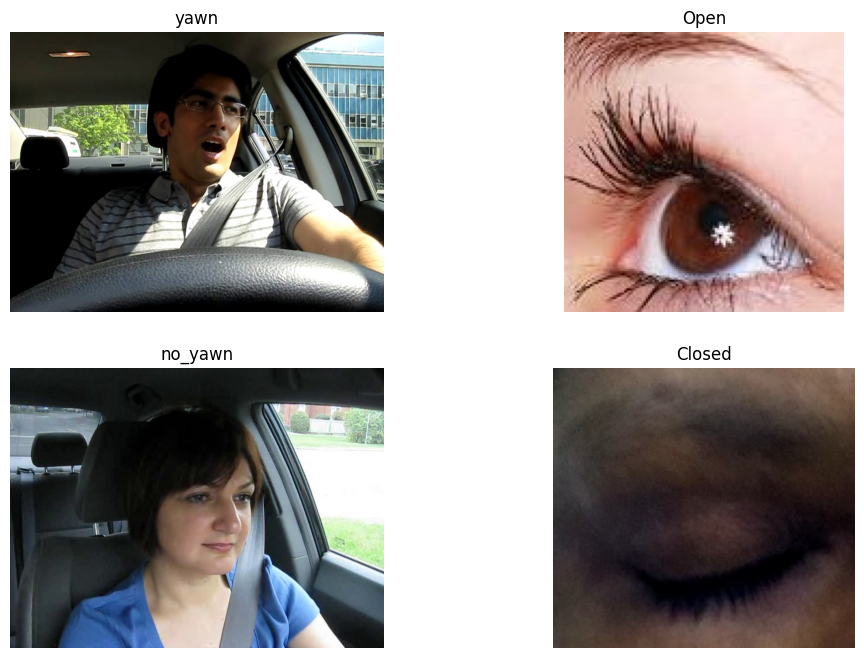

In [ ]:
# Display sample images from each class
import random

plt.figure(figsize=(12, 8))

classes = os.listdir(train_dir)

for i, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)

    # Pick a random image
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    # Read image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Plot
    plt.subplot(2, 2, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.show()

In [ ]:
#---🚀 STEP 3 — Data Preprocessing------------

In [ ]:
# Create ImageDataGenerator with validation split
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    brightness_range=[0.8,1.2],
    horizontal_flip=True,
    validation_split=0.3   # 30% data for val + test
)

In [ ]:
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=16,
    class_mode='categorical',
    subset='training'   # 70% data
)

Found 2049 images belonging to 4 classes.


In [ ]:
val_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=16,
    class_mode='categorical',
    subset='validation'   # 30% data (we will split later logically)
)

Found 874 images belonging to 4 classes.


In [ ]:
# Separate generator for test (no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2923 images belonging to 4 classes.


In [ ]:
print("Class Indices:", train_generator.class_indices)

Class Indices: {'Closed': 0, 'Open': 1, 'no_yawn': 2, 'yawn': 3}


In [ ]:
#----BUILD CNN MODEL-------

In [ ]:
# Import required layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build CNN model
model = Sequential()

# First Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Third Convolution Layer
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten the output
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))  # Prevent overfitting

# Output Layer (4 classes)
model.add(Dense(4, activation='softmax'))

# Print model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build fresh CNN model
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(4, activation='softmax'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train the model

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1258s 10s/step - accuracy: 0.6184 - loss: 0.7872 - val_accuracy: 0.7300 - val_loss: 0.5813
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 29s 226ms/step - accuracy: 0.7662 - loss: 0.4568 - val_accuracy: 0.6522 - val_loss: 0.5501
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 29s 228ms/step - accuracy: 0.7745 - loss: 0.4206 - val_accuracy: 0.7506 - val_loss: 0.4684
Epoch 4/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 29s 224ms/step - accuracy: 0.8014 - loss: 0.3785 - val_accuracy: 0.6728 - val_loss: 0.5429
Epoch 5/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 28s 219ms/step - accuracy: 0.7994 - loss: 0.3706 - val_accuracy: 0.6876 - val_loss: 0.5534
Epoch 6/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 29s 221ms/step - accuracy: 0.8145 - loss: 0.3493 - val_accuracy: 0.6808 - val_loss: 0.5626
Epoch 7/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 30s 233ms/step - accuracy: 0.8150 - loss: 0.3433 - val_accuracy: 0.7597 - val_loss: 0.5641
Epoch 8/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 29s 222ms/step - accuracy: 0.8468 - loss: 0

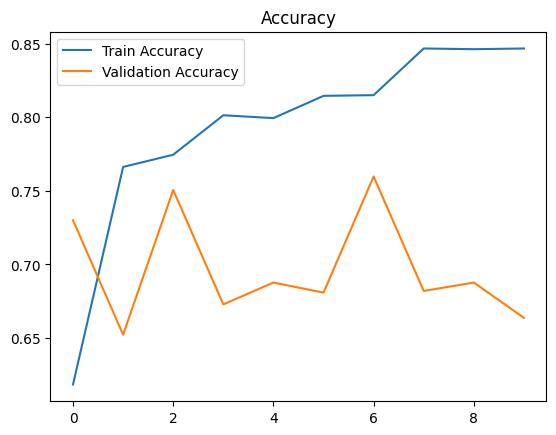

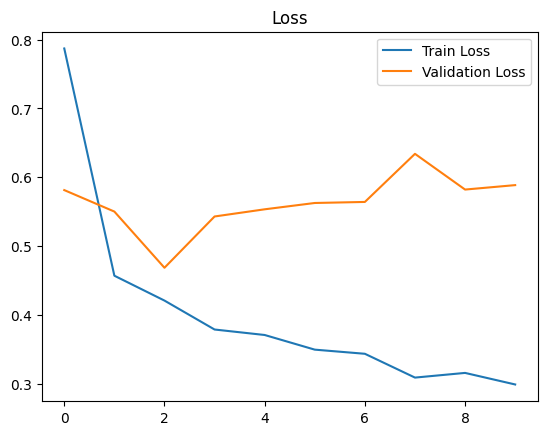

In [ ]:
# Plot training & validation accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

# Plot training & validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")
plt.show()

In [ ]:
# Save model to Google Drive
model.save('/content/drive/MyDrive/drowsiness_cnn_model.h5')

print("Model saved successfully!")

Model saved successfully!


In [ ]:
# Save in TensorFlow format
model.save('/content/drive/MyDrive/drowsiness_cnn_model.keras')

In [ ]:
import json

# Save history
with open('/content/drive/MyDrive/training_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
from tensorflow.keras.models import load_model

# Load model
model = load_model('/content/drive/MyDrive/drowsiness_cnn_model.keras')

print("Model loaded successfully!")

Model loaded successfully!


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
# Create test generator with the SAME image size used for training
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    train_dir,                 # using same folder temporarily
    target_size=(128, 128),    # must match trained model input
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

Found 2923 images belonging to 4 classes.


In [ ]:
#------🚀 NEXT STEP — MODEL EVALUATION (VERY IMPORTANT)

In [ ]:
# Evaluate model performance
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

183/183 ━━━━━━━━━━━━━━━━━━━━ 18s 93ms/step - accuracy: 0.8050 - loss: 0.3663
Test Accuracy: 0.8049948811531067
Test Loss: 0.36630696058273315


In [ ]:
# Get predictions
predictions = model.predict(test_generator)

# Convert predictions to class labels
predicted_classes = np.argmax(predictions, axis=1)

183/183 ━━━━━━━━━━━━━━━━━━━━ 15s 77ms/step


In [ ]:
# True labels
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print("Class Labels:", class_labels)

Class Labels: ['Closed', 'Open', 'no_yawn', 'yawn']


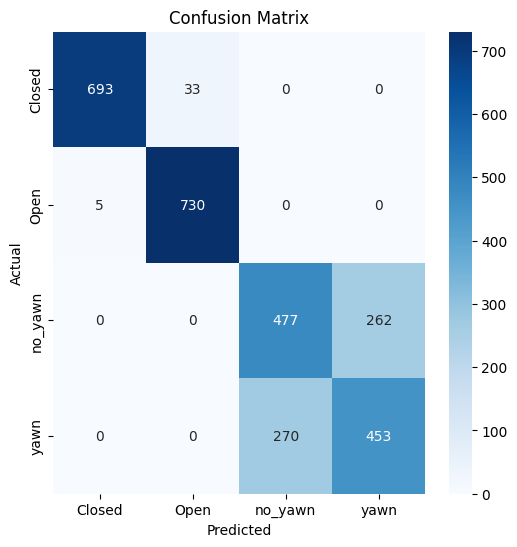

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot confusion matrix
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Print report
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

              precision    recall  f1-score   support

      Closed       0.99      0.95      0.97       726
        Open       0.96      0.99      0.97       735
     no_yawn       0.64      0.65      0.64       739
        yawn       0.63      0.63      0.63       723

    accuracy                           0.80      2923
   macro avg       0.81      0.80      0.80      2923
weighted avg       0.81      0.80      0.80      2923



In [ ]:
#------🚀 STEP 5 — MobileNetV2 (Transfer Learning)

In [ ]:
# Import MobileNetV2 (base model)
from tensorflow.keras.applications import MobileNetV2

# Load pretrained model without top layer
base_model = MobileNetV2(
    weights='imagenet',      # pretrained weights
    include_top=False,       # remove original classifier
    input_shape=(128, 128, 3)
)

# Freeze base model layers (important)
for layer in base_model.layers:
    layer.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Add custom classification layers
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

# Output layer (4 classes)
predictions = Dense(4, activation='softmax')(x)

# Final model
mobilenet_model = Model(inputs=base_model.input, outputs=predictions)

# Summary
mobilenet_model.summary()

Model: "functional_30"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
#compile mode
mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Training data
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),   # FIXED
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

# Validation data
val_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),   # FIXED
    batch_size=16,
    class_mode='categorical',
    subset='validation'
)

Found 2049 images belonging to 4 classes.
Found 874 images belonging to 4 classes.


In [ ]:
# Evaluate trained CNN model
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

183/183 ━━━━━━━━━━━━━━━━━━━━ 17s 93ms/step - accuracy: 0.8050 - loss: 0.3663
Test Accuracy: 0.8049948811531067
Test Loss: 0.36630696058273315


In [ ]:
# Get predictions
predictions = model.predict(test_generator)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

print("Class Labels:", class_labels)

183/183 ━━━━━━━━━━━━━━━━━━━━ 16s 85ms/step
Class Labels: ['Closed', 'Open', 'no_yawn', 'yawn']


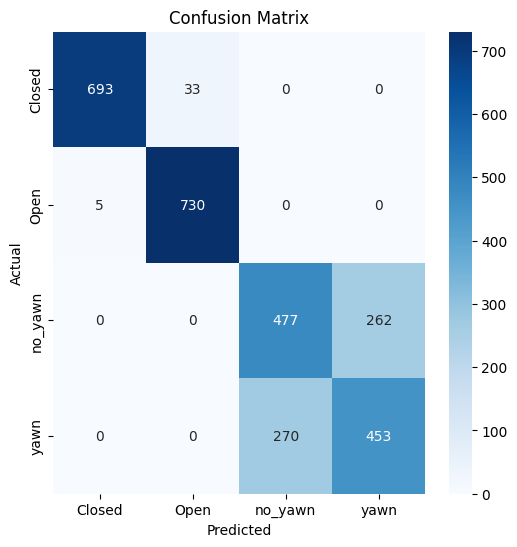

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(true_classes, predicted_classes, target_names=class_labels))

              precision    recall  f1-score   support

      Closed       0.99      0.95      0.97       726
        Open       0.96      0.99      0.97       735
     no_yawn       0.64      0.65      0.64       739
        yawn       0.63      0.63      0.63       723

    accuracy                           0.80      2923
   macro avg       0.81      0.80      0.80      2923
weighted avg       0.81      0.80      0.80      2923



In [ ]:
# Fatigue Detection Logic

# Now we convert 4-class output → 3 fatigue levels

# Define Mapping Logic
# Map class index to fatigue level
def get_fatigue_level(class_label):

    if class_label in ['Open', 'no_yawn']:
        return "Alert"

    elif class_label == 'yawn':
        return "Mild Fatigue"

    elif class_label == 'Closed':
        return "Severe Fatigue"

In [ ]:
# Convert predicted class index to labels
predicted_labels = [class_labels[i] for i in predicted_classes]

# Convert to fatigue levels
fatigue_levels = [get_fatigue_level(label) for label in predicted_labels]

# Print sample
for i in range(10):
    print(predicted_labels[i], "→", fatigue_levels[i])

Closed → Severe Fatigue
Closed → Severe Fatigue
Closed → Severe Fatigue
Closed → Severe Fatigue
Closed → Severe Fatigue
Closed → Severe Fatigue
Closed → Severe Fatigue
Closed → Severe Fatigue
Closed → Severe Fatigue
Closed → Severe Fatigue


In [ ]:
# Fatigue Progression Graph
# Convert fatigue levels to numbers
fatigue_map = {
    "Alert": 0,
    "Mild Fatigue": 1,
    "Severe Fatigue": 2
}

fatigue_numeric = [fatigue_map[level] for level in fatigue_levels]

In [ ]:
# Simulate time (each prediction = 1 frame)
time_steps = list(range(len(fatigue_numeric)))

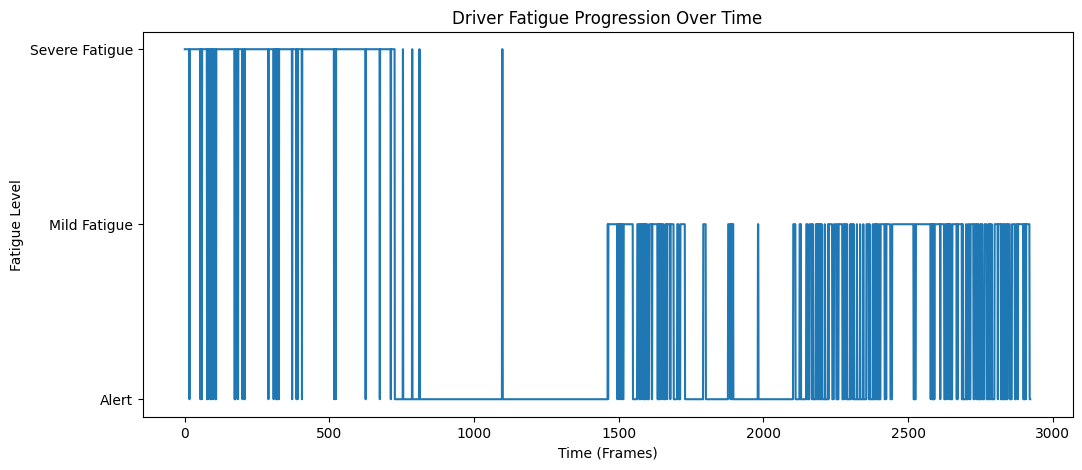

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(time_steps, fatigue_numeric)

plt.yticks([0,1,2], ["Alert", "Mild Fatigue", "Severe Fatigue"])
plt.xlabel("Time (Frames)")
plt.ylabel("Fatigue Level")
plt.title("Driver Fatigue Progression Over Time")

plt.show()

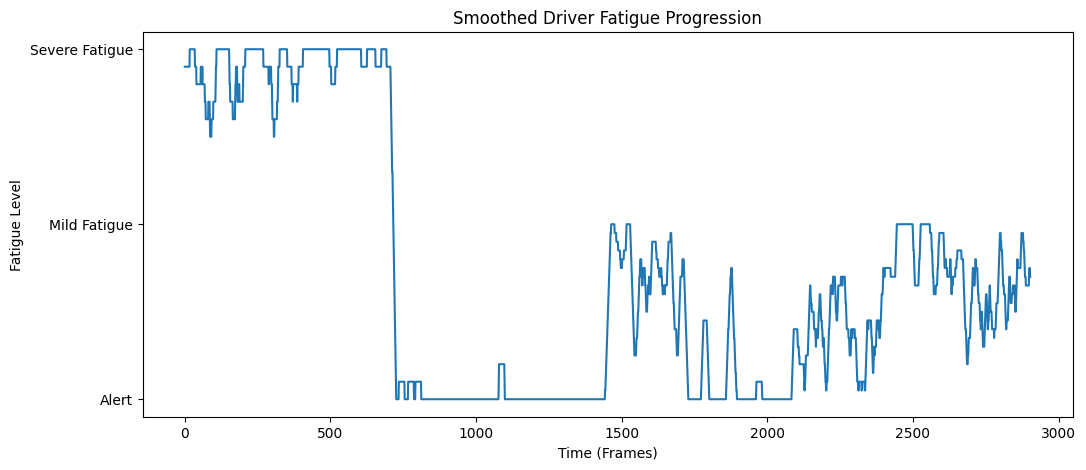

In [ ]:
# Smooth fatigue values (moving average)
import numpy as np

window_size = 20

smoothed = np.convolve(fatigue_numeric,
                       np.ones(window_size)/window_size,
                       mode='valid')

# Plot smoothed graph
plt.figure(figsize=(12,5))
plt.plot(smoothed)

plt.yticks([0,1,2], ["Alert", "Mild Fatigue", "Severe Fatigue"])
plt.xlabel("Time (Frames)")
plt.ylabel("Fatigue Level")
plt.title("Smoothed Driver Fatigue Progression")

plt.show()

In [ ]:
# Import MobileNetV2
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

# Load base model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

# Output layer
predictions = Dense(4, activation='softmax')(x)

# Final model
mobilenet_model = Model(inputs=base_model.input, outputs=predictions)

mobilenet_model.summary()

Model: "functional_31"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
#complile model
mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train model
history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 88s 533ms/step - accuracy: 0.7770 - loss: 0.4673 - val_accuracy: 0.7483 - val_loss: 0.4215
Epoch 2/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 31s 243ms/step - accuracy: 0.8575 - loss: 0.2992 - val_accuracy: 0.7883 - val_loss: 0.4211
Epoch 3/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 39s 228ms/step - accuracy: 0.8726 - loss: 0.2801 - val_accuracy: 0.7666 - val_loss: 0.4293
Epoch 4/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 29s 226ms/step - accuracy: 0.8809 - loss: 0.2450 - val_accuracy: 0.7208 - val_loss: 0.5087
Epoch 5/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 29s 229ms/step - accuracy: 0.9019 - loss: 0.2215 - val_accuracy: 0.7208 - val_loss: 0.5392


In [ ]:
# evaluate mobilenet
test_loss_m, test_acc_m = mobilenet_model.evaluate(test_generator)

print("MobileNet Accuracy:", test_acc_m)

183/183 ━━━━━━━━━━━━━━━━━━━━ 27s 150ms/step - accuracy: 0.8703 - loss: 0.2686
MobileNet Accuracy: 0.8703386783599854


In [ ]:
print("CNN Accuracy:", test_accuracy)
print("MobileNet Accuracy:", test_acc_m)

CNN Accuracy: 0.8049948811531067
MobileNet Accuracy: 0.8703386783599854
